# Exploratory Data Analysis (EDA) for Smart Mobility Inc
The goal of this EDA is to help our client(Smart Mobility Inc) aiming at developing smart mobility machine learning models and other technologies understand the "Smart Mobility Traffic Dataset" retrieved from Kaggel and stored on my github account(Phiona Namugga) under the EDA_Smart_Mobility_Traffic_Dataset folder.

The Traffic Optimization and Smart Mobility Dataset integrates data from social networks (SNs)and cyber-physical networks (CPNs) to enhance smart mobility and intelligent traffic management solutions. It includes vehicle telemetry,real-time traffic patterns, public transport efficiency,  ride-sharing demand, social media sentiment, and environmental factors.

This dataset is designed to support machine learning models for  mobility optimization,traffic congestion prediction, and smart city planning by analyzing key factors such as road occupancy,vehicle density, social media feedback, weather conditions, and emissions data.

## Objectives
 By identifying patterns,examining its variables,  and uncovering relationships that influence traffic congestion, the analysis aims to support machine learning model development for congestion prediction,smart city planning by exploring weather,traffic,mobility factors, social sentiment,environmental data  and mobility optimization.


## Cyber-Physical & Social Network Data for Intelligent Traffic Management
## Key Features
- Traffic Data:Speed,vehicle count, road occupancy, and traffic light status.
- Weather & Accidents: Accident reports, weather conditions and  impacting congestion.
- Social Network Sentiment: Public opinions on congestion and mobility from social media.
- Smart Mobility Factors: Parking availability,ride-sharing demand,  and public transport delays.
- Environmental Impact: CO₂ pollution and emissions levels.

## Target Variable
- Traffic Congestion Level: Categorized as Low, Medium, or High, based on traffic  speed,density, and road occupancy.
-This dataset is valuable for smart city developers, urban planners,  and AI researchers working on intelligent mobility solutions. 🚦🚗💡



## Importing libraries
This step involves importing libraries to be used for the exploratory data analysis in the Jupyter note book

In [2]:
import pandas as pd # imports pandas library
import numpy as np # imports numpy library used to
import seaborn as sns #used to create visual plots to be analyzed
import matplotlib.pyplot as plt #used to create visual plots to be analyzed
from scipy.stats import t,norm # carries out statistical analysis
from mpl_toolkits.mplot3d import Axes3D # carries out visualizations of 3D plots

## Data collection
This step involves importing the dataset from my Github aaccount in raw format and creating a data frame for it

In [3]:
### Loads csv file into the Jupyter notebook from my github account
df = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/EDA_Smart_Mobility_Traffic_Dataset/refs/heads/feature1/smart_mobility_dataset_with_NaN.csv')

In [ ]:
# Applying a purple-themed Seaborn style
sns.set_style("whitegrid")# White background with gridlines sns.set_palette("Purples")
sns.set_palette("Purples")  #- Purple color theme sns. set_context ("notebook", font_scale=1.2)
sns. set_context ("notebook", font_scale=1.2)  # - Set the font scale to 1.2

## Data cleaning
The data set has data quality issues(suffering from noise), it has null values which require cleaning out. The following steps have been undertaken to clean it.

Steps:
1. Checks for sum of null values in each column.
2. Imputes Null/missing values(displayed as NaN) since the dataset was found to be noisy
3. Fills missing values and verifies that none is still missing
4. Verifies if there are still missing values after imputing them.
5. Converts numerical values to float for easier analysis of the data.
6. Verifies/checks if there are any outliers
7. Checks if the dataset is balanced to ensure quality of the analysis

### Meta data:
- 5000 rows, 15 columns, integrating social networks (SNs) and cyber-physical networks(CPNs)
- 8 numeric columns (Traffic_Speed_kmh,Vehicle_Count, Road_Occupancy_%, Ride_Sharing_Demand,Sentiment_Score,  Parking_Availability, Emission_Levels_g_km, Energy_Consumption_L_h)
- 5 categorical columns (Weather_Condition, Traffic_Light_State,Traffic_Condition, Accident_Report,datetime Timestamp and Traffic Congestion Level).





In [ ]:
# Getting the sum of null values for each colunm in the dataset
df.isna().sum()

,0
Timestamp,75
Latitude,53
Longitude,75
Vehicle_Count,73
Traffic_Speed_kmh,69
Road_Occupancy_%,59
Traffic_Light_State,75
Weather_Condition,67
Accident_Report,60
Sentiment_Score,71


In [ ]:
# Imputing the NaN values
data_org = df.copy(deep=True)
# Converting timestamp to datetime
data_org['Timestamp'] = pd.to_datetime(data_org['Timestamp'], errors='coerce')
# Filling missing values
data_org['Timestamp'] = data_org['Timestamp'].fillna(data_org['Timestamp'].mode()[0])  # Using most frequent timestamp
data_org['Latitude'] = data_org['Latitude'].fillna(data_org['Latitude'].mean()) # Latitude (numeric, float) - filling the null values with the mean value of the latitudes
data_org['Longitude'] = data_org['Longitude'].fillna(data_org['Longitude'].mean()) # Longitude (numeric, float) - filling the null values with the mean value of the longitudes
data_org['Vehicle_Count'] = data_org['Vehicle_Count'].fillna(data_org['Vehicle_Count'].median()) # Vehicle_Count (numeric, integer) - filling the null values with median of the vehicle count since its robust to outliers
data_org['Traffic_Speed_kmh'] = data_org['Traffic_Speed_kmh'].fillna(data_org['Traffic_Speed_kmh'].mean()) # Traffic_Speed_kmh (numeric, float) - fills the null values with the mean of the Traffic_Speed data
data_org['Road_Occupancy_%'] = data_org['Road_Occupancy_%'].fillna(data_org['Road_Occupancy_%'].mean()) # Road_Occupancy_% (numeric, float, percentage) - fills the null values with the mean of the Road_Occupancy data
data_org['Traffic_Light_State'] = data_org['Traffic_Light_State'].fillna(data_org['Traffic_Light_State'].mode()[0])# Traffic_Light_State (categorical) - fills the null vlaues with the mode (most frequent value) of Traffic_Light_State  data
data_org['Weather_Condition'] = data_org['Weather_Condition'].fillna(data_org['Weather_Condition'].mode()[0]) # Weather_Condition (categorical) - fills the null values with mode of Weather_Condition data
data_org['Accident_Report'] = data_org['Accident_Report'].fillna(data_org['Accident_Report'].mode()[0]) # Accident_Report (categorical  or likely boolean) - fills the null vlaues with the mode of Accident_Report data
data_org['Sentiment_Score'] = data_org['Sentiment_Score'].fillna(data_org['Sentiment_Score'].mean()) # Sentiment_Score (numeric, float) - fills the null values with the mean of the Sentiment_Score data
data_org['Ride_Sharing_Demand'] = data_org['Ride_Sharing_Demand'].fillna(data_org['Ride_Sharing_Demand'].median()) # Ride_Sharing_Demand (numeric, likely integer) - fills the null values with the median of Ride_Sharing_Demand data
data_org['Parking_Availability'] = data_org['Parking_Availability'].fillna(data_org['Parking_Availability'].mean()) # Parking_Availability (numeric or categorical) - assuming numeric, fills the null values with the mean of Parking_Availability data
data_org['Emission_Levels_g_km'] = data_org['Emission_Levels_g_km'].fillna(data_org['Emission_Levels_g_km'].mean()) # Emission_Levels_g_km (numeric, float) - fills the null values with the mean of the Emission_Levels data
data_org['Energy_Consumption_L_h'] = data_org['Energy_Consumption_L_h'].fillna(data_org['Energy_Consumption_L_h'].mean()) # Energy_Consumption_L_h (numeric, float) - fills the null values with the mean of the Energy_Consumption data
data_org['Traffic_Condition'] = data_org['Traffic_Condition'].fillna(data_org['Traffic_Condition'].mode()[0]) # Traffic_Condition (categorical) - fills the null values with mode of the Traffic_Condition data


print("Missing values after cleaning:") # Verifying that the data cleaning has been done
print(data_org.isna().sum())

# Checking basic statistics to ensure cleaning makes sense
print("\nBasic statistics after cleaning:")
print(data_org.describe())

Missing values after cleaning:
Timestamp                 0
Latitude                  0
Longitude                 0
Vehicle_Count             0
Traffic_Speed_kmh         0
Road_Occupancy_%          0
Traffic_Light_State       0
Weather_Condition         0
Accident_Report           0
Sentiment_Score           0
Ride_Sharing_Demand       0
Parking_Availability      0
Emission_Levels_g_km      0
Energy_Consumption_L_h    0
Traffic_Condition         0
dtype: int64

Basic statistics after cleaning:
                        Timestamp     Latitude    Longitude  Vehicle_Count  \
count                        5000  5000.000000  5000.000000    5000.000000   
mean   2024-03-09 13:30:45.960000    40.749537   -73.847407     153.897200   
min           2024-03-01 00:00:00    40.600016   -73.999906      10.000000   
25%           2024-03-05 04:03:45    40.676269   -73.918660      81.000000   
50%           2024-03-09 13:32:30    40.749537   -73.847407     156.000000   
75%           2024-03-13 22:51:15 

In [ ]:
# Convert data  types from numerical to float for easier manipulation
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
numerical_cols = ['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
                'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability',
                'Emission_Levels_g_km', 'Energy_Consumption_L_h']
df[numerical_cols] = df[numerical_cols].astype(float)
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic_Condition']

In [ ]:
# Ascertaining if the data has outliers
print("\nOutlier Check:")
for col in numerical_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    print(f"{col}: {len(outliers)} outliers")


Outlier Check:
Latitude: 0 outliers
Longitude: 0 outliers
Vehicle_Count: 0 outliers
Traffic_Speed_kmh: 0 outliers
Road_Occupancy_%: 0 outliers
Sentiment_Score: 0 outliers
Ride_Sharing_Demand: 0 outliers
Parking_Availability: 0 outliers
Emission_Levels_g_km: 0 outliers
Energy_Consumption_L_h: 0 outliers


In [ ]:
# Ascertaining if the categorical columns below are balanced
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic_Condition']
# Creating function to check balance
def check_balance(df, column):
    # Counting frequencies
    counts = df[column].value_counts()
    total = len(df)
    percentages = (counts / total * 100).round(2)

    # Metrics for imbalance
    max_count = counts.max()
    min_count = counts.min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    # Print results
    print(f"\nBalance Check for '{column}':")
    print("Counts:\n", counts)
    print("Percentages:\n", percentages)
    print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
    if imbalance_ratio <= 1.5:
        print("-> Relatively Balanced")
    elif imbalance_ratio <= 3:
        print("-> Moderately Imbalanced")
    else:
        print("-> Highly Imbalanced")

# Checking for balance for each categorical column
for col in categorical_cols:
    check_balance(df, col)


Balance Check for 'Traffic_Light_State':
Counts:
 Traffic_Light_State
Yellow    1695
Green     1633
Red       1597
Name: count, dtype: int64
Percentages:
 Traffic_Light_State
Yellow    33.90
Green     32.66
Red       31.94
Name: count, dtype: float64
Imbalance Ratio (max/min): 1.06
-> Relatively Balanced

Balance Check for 'Weather_Condition':
Counts:
 Weather_Condition
Rain     1266
Snow     1241
Fog      1227
Clear    1199
Name: count, dtype: int64
Percentages:
 Weather_Condition
Rain     25.32
Snow     24.82
Fog      24.54
Clear    23.98
Name: count, dtype: float64
Imbalance Ratio (max/min): 1.06
-> Relatively Balanced

Balance Check for 'Accident_Report':
Counts:
 Accident_Report
0.0    4465
1.0     475
Name: count, dtype: int64
Percentages:
 Accident_Report
0.0    89.3
1.0     9.5
Name: count, dtype: float64
Imbalance Ratio (max/min): 9.40
-> Highly Imbalanced

Balance Check for 'Traffic_Condition':
Counts:
 Traffic_Condition
High      3138
Medium    1454
Low        358
Name: cou

## Univariet analysis
It examines the distribution of each numeric variable, one at a time.It helps in:
- Understanding the shape of the data (e.g. skewed, normal, bimodal).
- Assessing range and variability (e.g.,wide spread vs narrow).
- Identifying central tendency (e.g., where most values lie).
- Spotting outliers or unusual patterns (e.g., spikes, gaps).


### Qn1: How does traffic distribution conditions highlight opportunities for smart mobility solutions?

### Ans:
As illustrated in the pie chart below,
- Heavy traffic which is at 63.4 % occurance in our sample area indicates high congestion which neccessitates solutions like dynamic routing when implementing smart mobility solutions.
- The medium traffic indicates 29.4% occurance, is moderately low and this neccesitating for majority planning for heavy traffic conditions.
- Light traffic conditions have 7.2% of occurance and thus there is need to mainly develop solutions for heavy traffic.


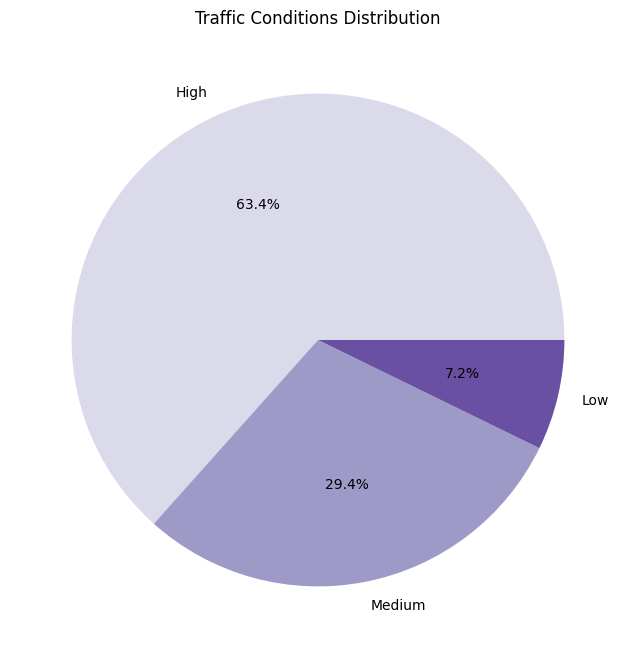

In [6]:
# Analyzing the occurrence of each Traffic_Condition.
Traffic_Condition_Counts = df['Traffic_Condition'].value_counts()
# Drawing pie chart
plt.figure(figsize=(8, 8))
plt.pie(Traffic_Condition_Counts, labels=Traffic_Condition_Counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Purples', len(Traffic_Condition_Counts)))
plt.title('Traffic Conditions Distribution')
plt.show()

### Qn2:
How do the weather conditions reveal opportunities for adapting smart mobility?

### Ans:
As revealed in the pie chart below:
The weather conditons neccessitate the need for factoring percentage occurance of 25.2% snow, 25.7% rain, 24.9% fog and 24.3% when developing smart mobility solutions that will be resilient and sustainable for the area.

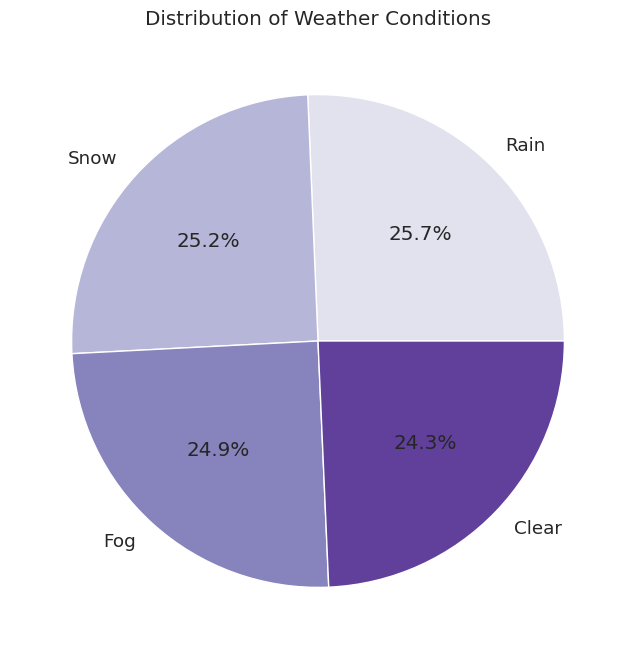

In [ ]:
# Visualization of occurrences of each Weather_Condition.
weather_counts = df['Weather_Condition'].value_counts()
# Drawing Pie chart
plt.figure(figsize=(8, 8))
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Purples', len(weather_counts)))
plt.title('Distribution of Weather Conditions')
plt.show()

## Bivariet analysis

### Qn 3:
How do the relationships between  traffic speed, vehicle count,traffic conditions,geographic location , and time reveal actionable strategies for enhancing smart mobility efficiency and reducing urban congestion?

Ans:
As revealed below:
Vehicle_Count vs Traffic_Speed_kmh (Scatter-plot): If high vehicle counts correlate with low speeds, it suggests congestion thresholds—strategy: increase ride-sharing during high-count periods.

Traffic_Speed_kmh vs Traffic_Condition (Box-plot): Lower speeds in “Heavy” vs “Light” conditions highlight congestion impacts—strategy: adjust traffic light cycles for Heavy conditions.

Timestamp vs Vehicle_Count (Line-graph): Peaks at 8 AM and 5 PM indicate rush hours—strategy: deploy dynamic routing or extra buses during these times.

Latitude vs Longitude (Scatter-plot): Clusters of points reveal busy zones—strategy: target infrastructure upgrades or parking solutions in high-density areas.

### Qn4:
How does the hourly variation in vehicle count reveal opportunities for optimizing traffic management and resources allocation?

### Ans:
As revealed below;
The Hourly Variations, show vehicle counts between the different hours of the day. Peaks have been observed at 10 hours(10AM) which is anticipated to be the morning rush hour when people are going to work, 19 hours(7PM) which is anticipated to be the time when people are returning from work and at 1 hour(1AM) which anticipated to be a time when people are going to party. This suggests that there is need to deploy more dynamic traffic controls or extra resources like buses during these periods when developing solutions.

Low traffic periods e.g 9hrs(9AM) suggest, underutilized periods thus an opportunity to reduce resource like buses, servers for routing options and other interventions.


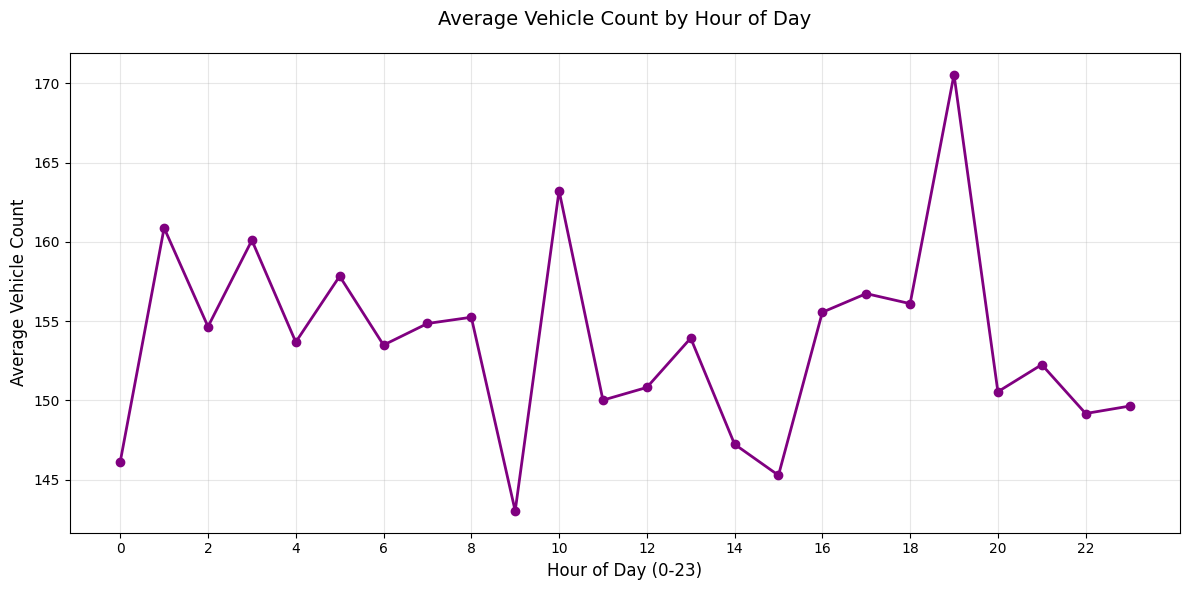

Hourly Vehicle Count Summary:
count     24.000000
mean     153.792496
std        6.120363
min      143.035533
25%      149.926234
50%      153.805879
75%      156.263156
max      170.548223
Name: Vehicle_Count, dtype: float64


In [11]:
# Ensuring datetime timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')  # 'coerce' handles invalid values
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
# Line plot: Timestamp vs Vehicle_Count
df_aggr = df.groupby(df['Timestamp'].dt.hour)['Vehicle_Count'].mean()
plt.figure(figsize=(12, 6))
plt.plot(df_aggr.index, df_aggr.values, color='purple', linewidth=2, marker='o', markersize=6)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Vehicle Count', fontsize=12)
plt.title('Average Vehicle Count by Hour of Day', fontsize=14, pad=20)
plt.xticks(range(0, 24, 2), fontsize=10)  # Every 2 hours for clarity
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Printing summary statistics
print("Hourly Vehicle Count Summary:")
print(df_aggr.describe())

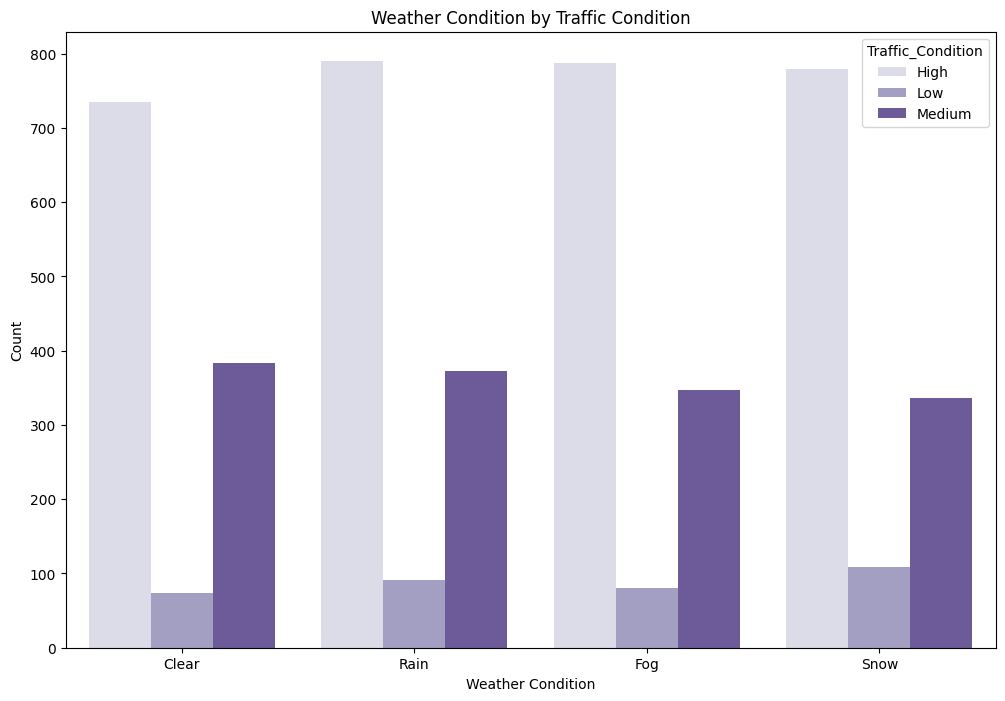

In [9]:
# Bar plot analyzing weather condtions during the different traffic conditions
plt.figure(figsize=(12, 8))
sns.countplot(x='Weather_Condition', hue='Traffic_Condition', data=df, palette='Purples')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.title('Weather Condition by Traffic Condition')
plt.show()

### Qn5:
How does the distribution of traffic speeds, compared to an idealized Gaussian model, reveal opportunities for optimizing urban traffic flow and identifying speed-related congestion thresholds?

### Ans:
The visual analysis below shows:
Peak speeds occur between 30-50 km/h(e.g., mean ~40 km/h). This implies that when developing smart mboility solutions, these ranges can be maintained as an optimal flow range.

Left tail shows speeds of ~20 km/h which is the potential congestion threshold thus needing intervention.

The Gaussian curve confirms mean(μ)=42.2, standard deviaiton(σ)=21.7

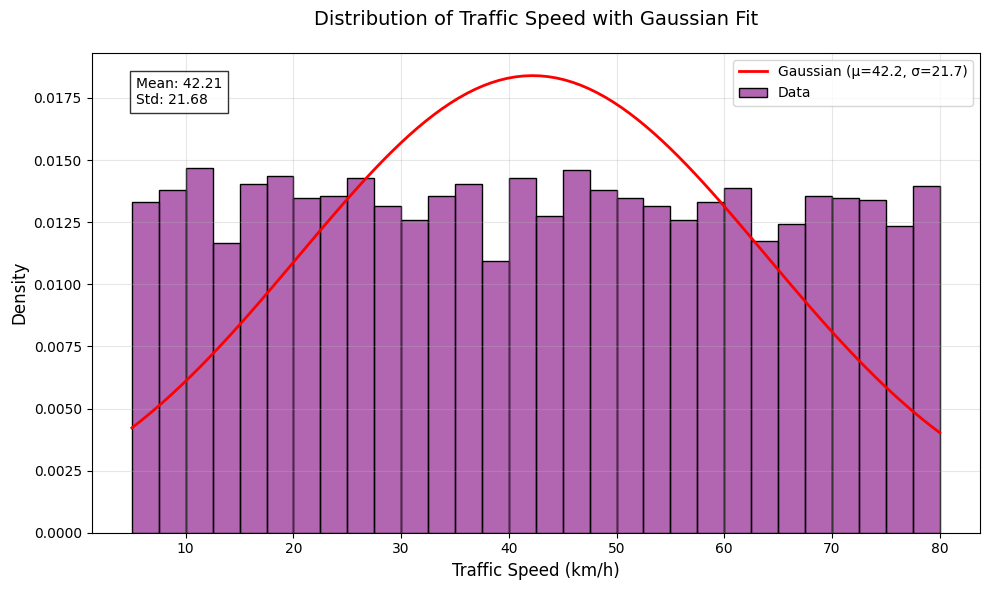

In [14]:
# Creating a dataframe for the data
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)
# Calculating mean and standard deviation
m = df['Traffic_Speed_kmh'].mean()
sigma = df['Traffic_Speed_kmh'].std()
plt.figure(figsize=(10, 6))
# Ploting histogram with density (normalized)
sns.histplot(df['Traffic_Speed_kmh'], bins=30, color='purple', stat='density', alpha=0.6, label='Data')
# Generating points for Gaussian curve
x = np.linspace(df['Traffic_Speed_kmh'].min(), df['Traffic_Speed_kmh'].max(), 100)
gaussian = norm.pdf(x, m, sigma)
plt.plot(x, gaussian, 'r-', lw=2, label=f'Gaussian (μ={m:.1f}, σ={sigma:.1f})')
# Customizing plot
plt.xlabel('Traffic Speed (km/h)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.title('Distribution of Traffic Speed with Gaussian Fit', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Displaying mean and standard deviation on the plot
plt.text(0.05, 0.95, f'Mean: {m:.2f}\nStd: {sigma:.2f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

How do the geographic distribution of vehicle counts across different hours of the day reveal opportunities for optimizing traffic flow and deploying location-specific mobility solutions to reduce urban congestion?

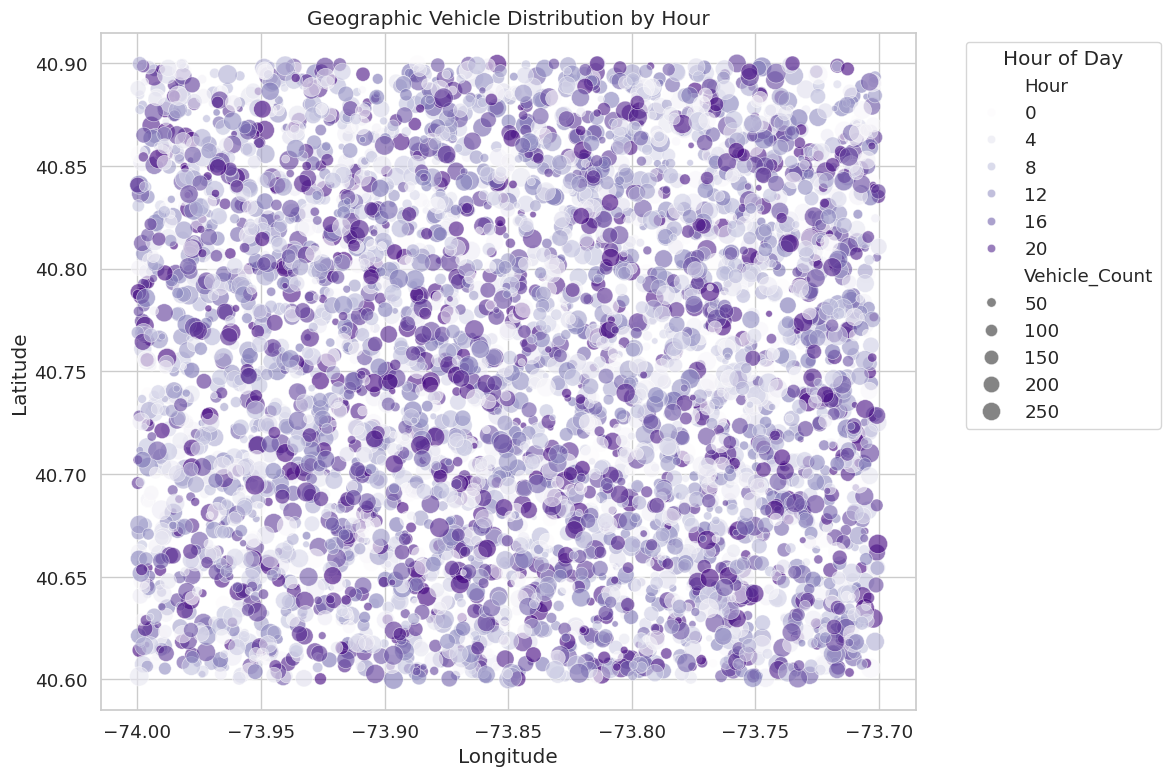

In [ ]:
# Preparing data
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour  # Extract hour for hue
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)

# Bubble plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Longitude', y='Latitude', size='Vehicle_Count', hue='Hour',
                data=df, palette='Purples', alpha=0.6, sizes=(20, 200))

plt.title('Geographic Vehicle Distribution by Hour')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Hour of Day', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Multivariet Analysis

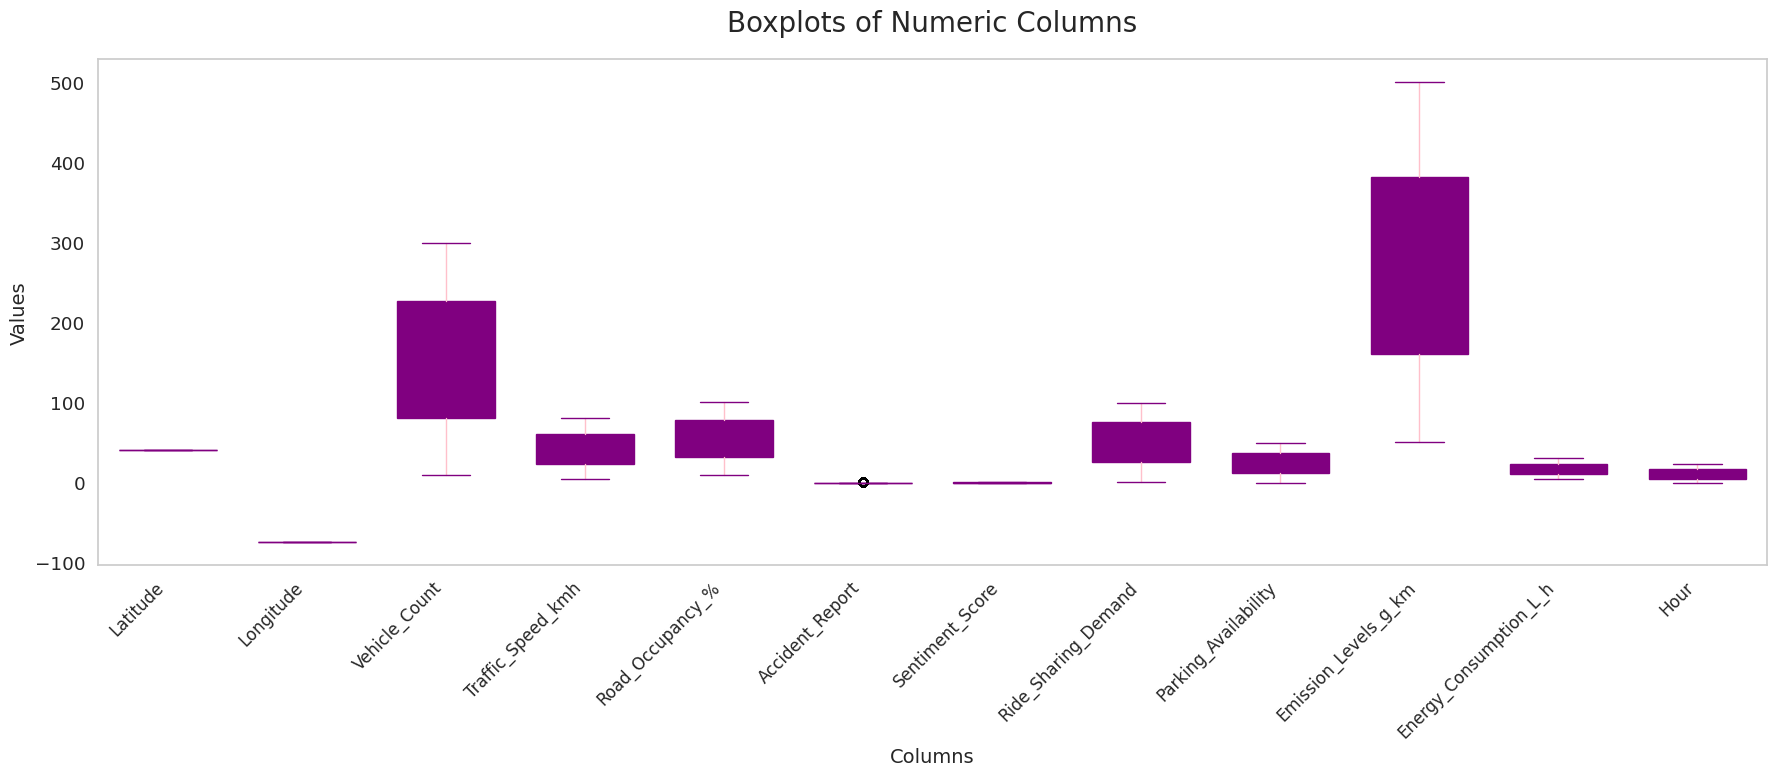

In [ ]:
# Using numerical columns only
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df[numeric_cols]


plt.figure(figsize=(18, 8))

# Box plot
box = df_numeric.boxplot(grid=False, color=dict(boxes='purple', whiskers='purple', medians='purple', caps='purple'),
                         patch_artist=True,  # Required for filled boxes
                         widths=0.7)  # Wider boxes for visibility

# Customize title and labels
plt.title("Boxplots of Numeric Columns", fontsize=20, pad=20)
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Values", fontsize=14)

# Slant x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

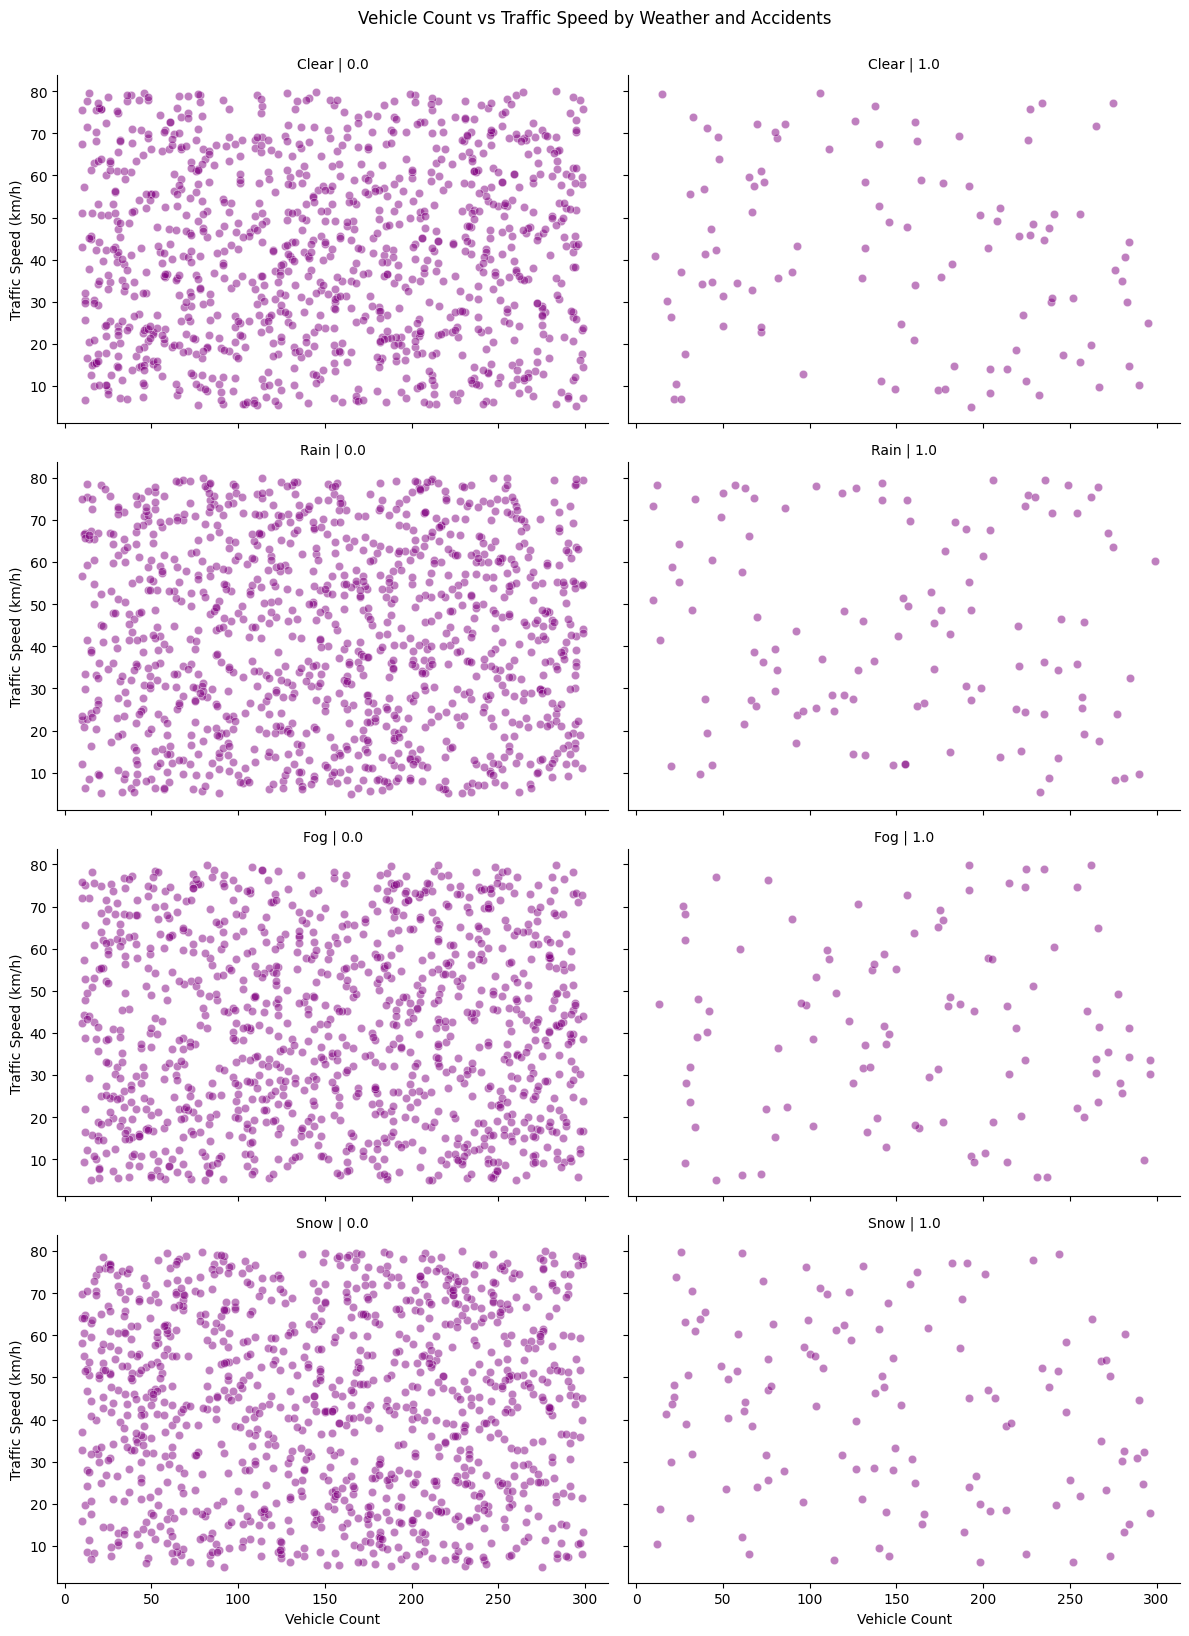

In [ ]:
# Preparing data
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Facet grid
g = sns.FacetGrid(df, row='Weather_Condition', col='Accident_Report', height=4, aspect=1.5)
g.map(sns.scatterplot, 'Vehicle_Count', 'Traffic_Speed_kmh', color='purple', alpha=0.5)
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.set_axis_labels('Vehicle Count', 'Traffic Speed (km/h)')
g.fig.suptitle('Vehicle Count vs Traffic Speed by Weather and Accidents', y=1.02)
plt.show()

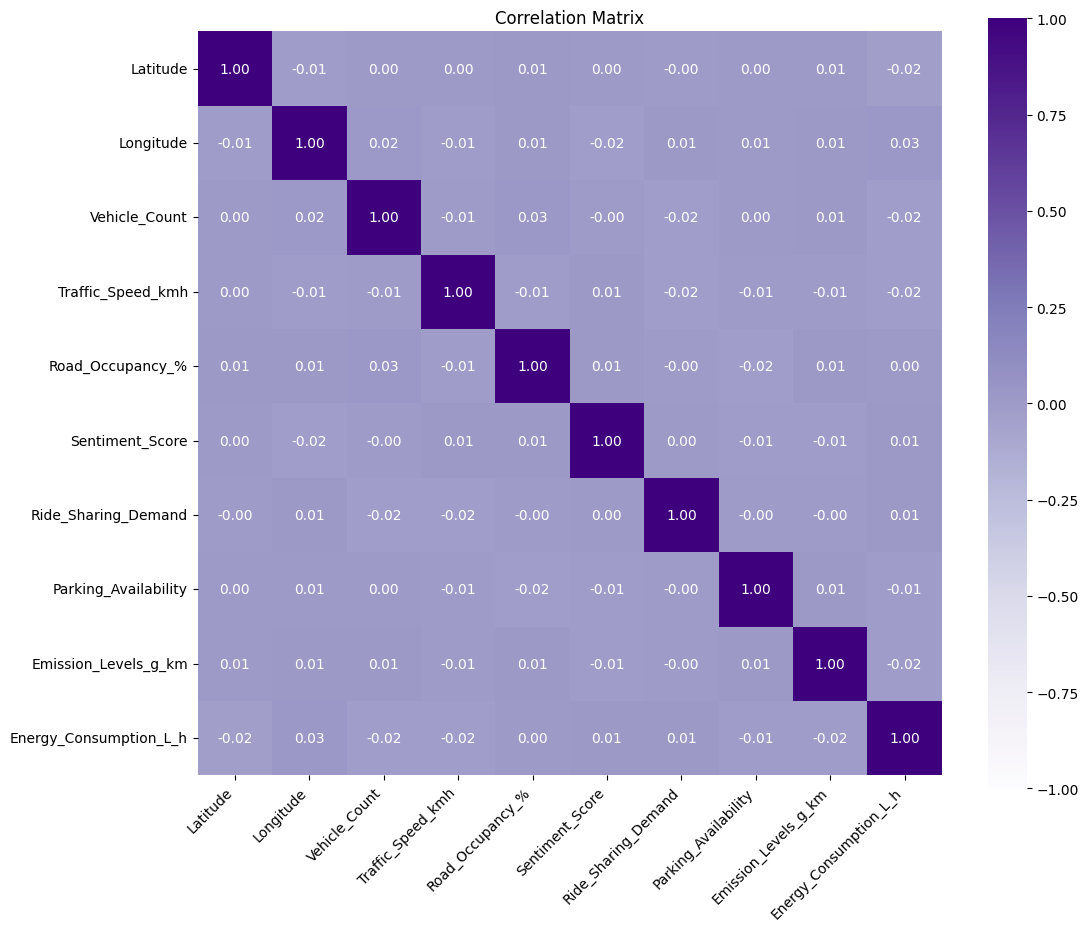

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Purples', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

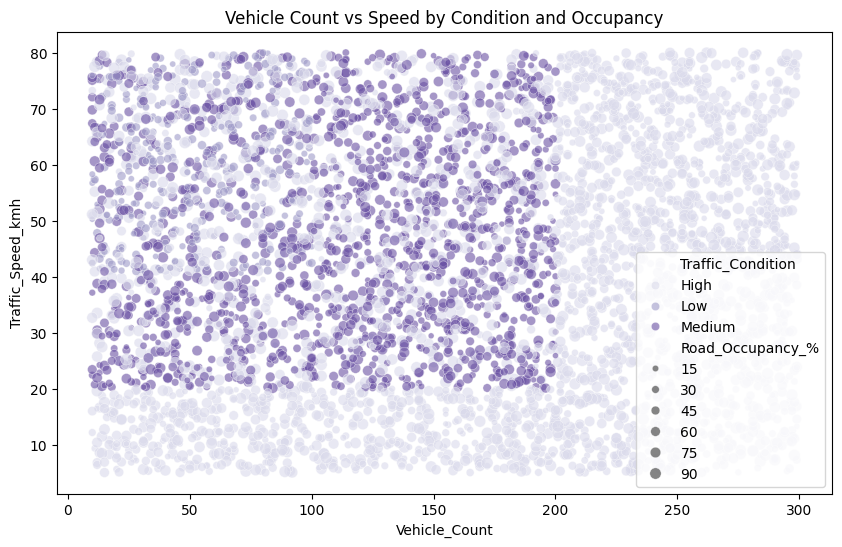

In [ ]:


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Vehicle_Count', y='Traffic_Speed_kmh', hue='Traffic_Condition',
                size='Road_Occupancy_%', data=df, palette='Purples', alpha=0.6)
plt.title('Vehicle Count vs Speed by Condition and Occupancy')
plt.show()


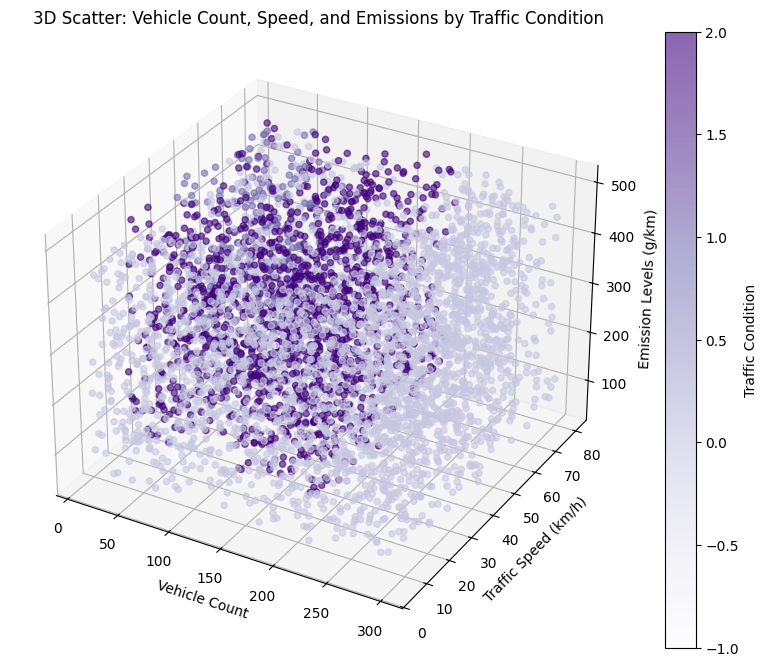

In [ ]:
# Preparing data
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)
df['Emission_Levels_g_km'] = df['Emission_Levels_g_km'].astype(float)

# 3D Scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Vehicle_Count'], df['Traffic_Speed_kmh'], df['Emission_Levels_g_km'],
                     c=pd.factorize(df['Traffic_Condition'])[0], cmap='Purples', alpha=0.6)

ax.set_xlabel('Vehicle Count')
ax.set_ylabel('Traffic Speed (km/h)')
ax.set_zlabel('Emission Levels (g/km)')
plt.title('3D Scatter: Vehicle Count, Speed, and Emissions by Traffic Condition')
plt.colorbar(scatter, label='Traffic Condition')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

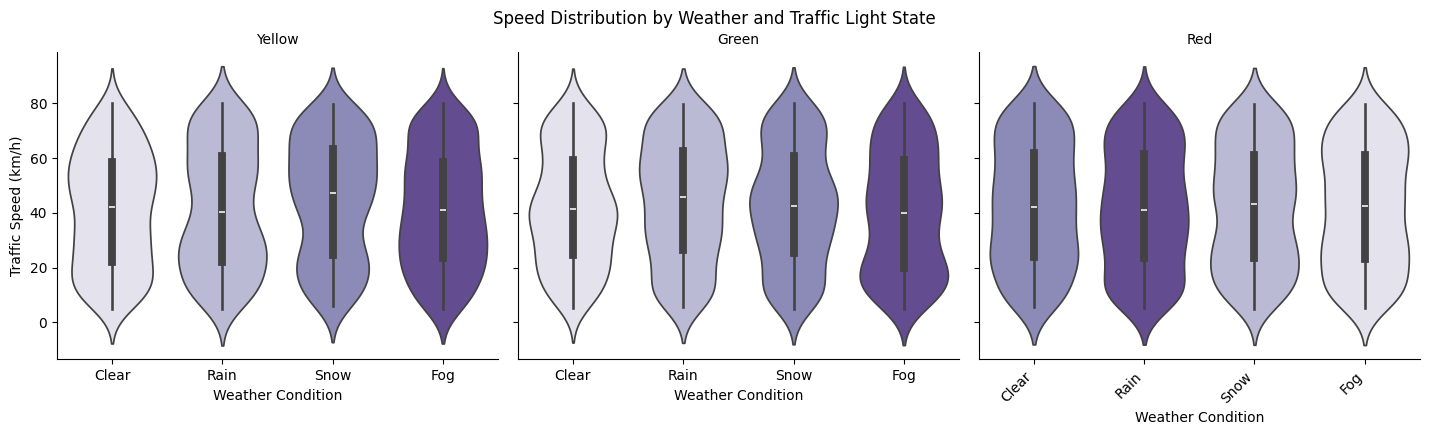

In [ ]:
# Preparing data
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Faceted violin plot
g = sns.FacetGrid(df, col='Traffic_Light_State', height=4, aspect=1.2)
g.map(sns.violinplot, 'Weather_Condition', 'Traffic_Speed_kmh', palette='Purples')
g.set_titles('{col_name}')
g.set_axis_labels('Weather Condition', 'Traffic Speed (km/h)')
g.fig.suptitle('Speed Distribution by Weather and Traffic Light State', y=1.02)
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# 2. Summary Statistics
print("\nNumeric Summary:")
print(df[numeric_cols].describe())
print("\nCategorical Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Numeric Summary:
          Latitude    Longitude  Vehicle_Count  Traffic_Speed_kmh  \
count  4947.000000  4925.000000    4927.000000        4931.000000   
mean     40.749537   -73.847407     153.866044          42.210544   
std       0.086091     0.086148      83.611289          21.681495   
min      40.600016   -73.999906      10.000000           5.002789   
25%      40.675375   -73.919971      80.000000          23.410557   
50%      40.748536   -73.845912     156.000000          42.370915   
75%      40.824719   -73.771690     226.000000          60.825507   
max      40.899972   -73.700159     299.000000          79.997556   

       Road_Occupancy_%  Sentiment_Score  Ride_Sharing_Demand  \
count       4941.000000      4929.000000          4929.000000   
mean          54.772394        -0.005020            50.358491   
std           26.138992         0.583732            28.450735   
min           10.005031        -0.999819             1.000000   
25%           32.107815        -0.4

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(df['Traffic_Speed_kmh'])
print(f'Shapiro Test: p-value={p:.4f}')  # p > 0.05 suggests normality

Shapiro Test: p-value=nan


In [ ]:

# Define categorical columns
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic_Condition']

# Function to check balance
def check_balance(df, column):
    # Count frequencies
    counts = df[column].value_counts()
    total = len(df)
    percentages = (counts / total * 100).round(2)

    # Metrics for imbalance
    max_count = counts.max()
    min_count = counts.min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    # Print results
    print(f"\nBalance Check for '{column}':")
    print("Counts:\n", counts)
    print("Percentages:\n", percentages)
    print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
    if imbalance_ratio <= 1.5:
        print("-> Relatively Balanced")
    elif imbalance_ratio <= 3:
        print("-> Moderately Imbalanced")
    else:
        print("-> Highly Imbalanced")


# Check balance for each categorical column
for col in categorical_cols:
    check_balance(df, col)


Balance Check for 'Traffic_Light_State':
Counts:
 Traffic_Light_State
Yellow    1695
Green     1633
Red       1597
Name: count, dtype: int64
Percentages:
 Traffic_Light_State
Yellow    33.90
Green     32.66
Red       31.94
Name: count, dtype: float64
Imbalance Ratio (max/min): 1.06
-> Relatively Balanced

Balance Check for 'Weather_Condition':
Counts:
 Weather_Condition
Rain     1266
Snow     1241
Fog      1227
Clear    1199
Name: count, dtype: int64
Percentages:
 Weather_Condition
Rain     25.32
Snow     24.82
Fog      24.54
Clear    23.98
Name: count, dtype: float64
Imbalance Ratio (max/min): 1.06
-> Relatively Balanced

Balance Check for 'Accident_Report':
Counts:
 Accident_Report
0.0    4465
1.0     475
Name: count, dtype: int64
Percentages:
 Accident_Report
0.0    89.3
1.0     9.5
Name: count, dtype: float64
Imbalance Ratio (max/min): 9.40
-> Highly Imbalanced

Balance Check for 'Traffic_Condition':
Counts:
 Traffic_Condition
High      3138
Medium    1454
Low        358
Name: cou

In [ ]:
# Check for constant columns
constant_cols = df.columns[df.nunique() == 1]
print("Constant Columns:", constant_cols)


Constant Columns: Index([], dtype='object')


In [ ]:
valid_numerical_columns = ['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h']

# Generate detailed descriptive statistics for numeric columns
desc_stats = df[valid_numerical_columns].describe().T

# Compute skewness for each numeric column
skewness = df[valid_numerical_columns].skew()
print("\nSkewness:")
print(skewness)

# Compute kurtosis for each numeric column
kurtosis = df[valid_numerical_columns].kurt()
print("\nKurtosis:")
print(kurtosis)



Skewness:
Latitude                 -0.001739
Longitude                -0.052108
Vehicle_Count            -0.015535
Traffic_Speed_kmh         0.019578
Road_Occupancy_%          0.000431
Sentiment_Score           0.006666
Ride_Sharing_Demand       0.012975
Parking_Availability      0.006721
Emission_Levels_g_km      0.018016
Energy_Consumption_L_h    0.047860
dtype: float64

Kurtosis:
Latitude                 -1.202092
Longitude                -1.183599
Vehicle_Count            -1.206749
Traffic_Speed_kmh        -1.199238
Road_Occupancy_%         -1.202289
Sentiment_Score          -1.212059
Ride_Sharing_Demand      -1.177209
Parking_Availability     -1.207525
Emission_Levels_g_km     -1.186376
Energy_Consumption_L_h   -1.187501
dtype: float64


## Inferential Statistics

H0: There is no significant difference between good and bad quality Apples
H1: There is a significant difference between good and bad quality Apples

In [ ]:
# T-test for Traffic_Speed_kmh by Traffic_Condition
from scipy import stats


In [ ]:
# Chi-square test for Traffic_Condition and Accident_Report
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Traffic_Speed_kmh'], df['Accident_Report'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square (chi2),p-value(chi_p), Degrees of Freedom{dof}")

print(f"Chi-square Test: p-value={p:.4f}")

Chi-square (chi2),p-value(chi_p), Degrees of Freedom4870
Chi-square Test: p-value=0.4933


In [ ]:
# ANOVA for Traffic_Speed_kmh by Traffic_Condition
from scipy.stats import f_oneway    # Import ANOVA function


In [ ]:
# Confidence Interval for Traffic_Speed_kmh
from scipy.stats import t
import numpy as np  # Import numpy for array operations


In [16]:
!jupyter nbconvert --execute --to html "/content/smart_mobility_traffic2.ipynb"

[NbConvertApp] Converting notebook /content/smart_mobility_traffic2.ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 3961752 bytes to /content/smart_mobility_traffic2.html


In [19]:
import json

# Replace 'your_notebook.ipynb' with your actual notebook filename
with open("smart_mobility_traffic2.ipynb", "r", encoding="utf-8") as f:
    notebook_content = json.load(f)

# Convert notebook content to string and count characters
char_count = len(json.dumps(notebook_content))
print(f"Total number of characters in the notebook: {char_count}")


Total number of characters in the notebook: 3380202
